<a href="https://colab.research.google.com/github/nehansa2003/NLP_project/blob/main/Final_Unseen_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import json
import numpy as np
import pandas as pd
import torch
from transformers import (AutoTokenizer,AutoModelForSequenceClassification)
from torch.utils.data import DataLoader, TensorDataset
from scipy.special import softmax
from sklearn.metrics import accuracy_score
from sklearn.metrics import (precision_recall_fscore_support)
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive



In [2]:
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/Game_Review_NLP'

FINAL_MODEL_DIR = (
    f'{PROJECT_PATH}/final_distilbert_game_sentiment'
)

print("Model directory:")
print(FINAL_MODEL_DIR)

print("\nFiles:")
print(os.listdir(FINAL_MODEL_DIR))

Mounted at /content/drive
Model directory:
/content/drive/MyDrive/Game_Review_NLP/final_distilbert_game_sentiment

Files:
['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json', 'training_args.bin', 'threshold_config.json']


Load tokenizer and model

In [3]:
tokenizer = AutoTokenizer.from_pretrained(
    FINAL_MODEL_DIR
)

model = AutoModelForSequenceClassification.from_pretrained(
    FINAL_MODEL_DIR
)

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

model.to(device)
model.eval()

print("Device:", device)
print("Model loaded successfully.")

Loading weights:   0%|          | 0/104 [00:01<?, ?it/s]

Device: cpu
Model loaded successfully.


Load the unseen dataset

In [4]:
unseen_df = pd.read_csv(
    f'{PROJECT_PATH}/unseen_reviews_v2.csv'
)

print("Unseen dataset shape:", unseen_df.shape)

display(
    unseen_df.head()
)

Unseen dataset shape: (2660, 19)


,game_id,game_name,game_url,review_id,author,outlet,score,date,review_text,review_url,clean_review_text,word_count,score_normalized,sentiment,score_normalized_v2,sentiment_v2,score_normalized_v3,sentiment_v3,sentiment_final
0,124,Rogue Legacy 2,https://opencritic.com/game/13069/rogue-legacy-2,4a21b554-7db5-4cad-882a-620dc0766357,Anne Marie Coyle,PC Gamer,88 / 100,4-May-22,A sublime addition to the Rogue Legacy family ...,https://www.pcgamer.com/rogue-legacy-2-review/,a sublime addition to the rogue legacy family ...,15,88.0,positive,88.0,positive,88.0,positive,positive
1,124,Rogue Legacy 2,https://opencritic.com/game/13069/rogue-legacy-2,c5dd4487-7506-4873-943d-d7328880b851,Mitchell Saltzman,IGN,9 / 10.0,28-Apr-22,Rogue Legacy 2 honors its own legacy as the pr...,https://www.ign.com/articles/rogue-legacy-2-re...,rogue legacy 2 honors its own legacy as the pr...,35,90.0,positive,90.0,positive,90.0,positive,positive
2,124,Rogue Legacy 2,https://opencritic.com/game/13069/rogue-legacy-2,eace1412-acb9-47e8-bf04-6941eb97e8d4,Caelyn Ellis,Eurogamer,Recommended,28-Apr-22,Rogue Legacy 2 really is a lovely game and I’m...,https://www.eurogamer.net/rogue-legacy-2-revie...,rogue legacy 2 really is a lovely game and i m...,50,NaN,NaN,NaN,NaN,85.0,positive,positive
3,124,Rogue Legacy 2,https://opencritic.com/game/13069/rogue-legacy-2,869da2e0-ff5b-40d6-ad2b-c484a254cf2f,George Foster,TheGamer,4 stars,28-Apr-22,"Beyond the heavy grind, which is certainly pur...",https://www.thegamer.com/rogue-legacy-2-review/,"beyond the heavy grind, which is certainly pur...",70,80.0,positive,80.0,positive,80.0,positive,positive
4,124,Rogue Legacy 2,https://opencritic.com/game/13069/rogue-legacy-2,f2860120-8a5a-4f8b-876c-e40601ab0f48,John Carson,Game Informer,9 / 10.0,11-May-22,"Despite my nitpicks, every new discovery unvei...",https://www.gameinformer.com/review/rogue-lega...,"despite my nitpicks, every new discovery unvei...",74,90.0,positive,90.0,positive,90.0,positive,positive


Verification

In [5]:
train_df = pd.read_csv(
    f'{PROJECT_PATH}/train_reviews_v2.csv'
)

test_df = pd.read_csv(
    f'{PROJECT_PATH}/test_reviews_v2.csv'
)

train_games = set(
    train_df['game_id'].unique()
)

test_games = set(
    test_df['game_id'].unique()
)

unseen_games = set(
    unseen_df['game_id'].unique()
)

print("GAME SEPARATION CHECK")
print("=" * 60)

print(
    "Training ∩ Unseen:",
    len(train_games & unseen_games)
)

print(
    "Testing ∩ Unseen:",
    len(test_games & unseen_games)
)

print(
    "Unseen games:",
    len(unseen_games)
)

GAME SEPARATION CHECK
Training ∩ Unseen: 0
Testing ∩ Unseen: 0
Unseen games: 50


Load the frozen threshold

In [6]:
with open(
    f'{FINAL_MODEL_DIR}/threshold_config.json',
    'r'
) as f:

    threshold_config = json.load(f)

BEST_NEGATIVE_THRESHOLD = (
    threshold_config['negative_threshold']
)

print(
    "Frozen negative threshold:",
    BEST_NEGATIVE_THRESHOLD
)

Frozen negative threshold: 0.3


Prepare unseen review text

In [7]:
print("Total unseen reviews:", len(unseen_df))

print(
    "Reviews with text:",
    unseen_df['review_text'].notna().sum()
)

print(
    "Reviews without text:",
    unseen_df['review_text'].isna().sum()
)

Total unseen reviews: 2660
Reviews with text: 2660
Reviews without text: 0


In [8]:
unseen_prediction_df = unseen_df[
    unseen_df['review_text'].notna()
].copy()

unseen_prediction_df['review_text'] = (
    unseen_prediction_df['review_text']
    .astype(str)
)

print(
    "Reviews available for prediction:",
    len(unseen_prediction_df)
)

Reviews available for prediction: 2660


Create label mappings

In [9]:
label2id = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

id2label = {
    0: 'negative',
    1: 'neutral',
    2: 'positive'
}

Tokenize unseen reviews

In [10]:
encodings = tokenizer(
    unseen_prediction_df['review_text'].tolist(),
    truncation=True,
    max_length=512,
    padding=True,
    return_tensors='pt'
)

print(
    "Tokenized reviews:",
    len(unseen_prediction_df)
)

Tokenized reviews: 2660


Generate predictions

In [11]:
batch_size = 16

dataset = TensorDataset(
    encodings['input_ids'],
    encodings['attention_mask']
)

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=False
)

all_logits = []

with torch.no_grad():

    for batch in loader:

        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        all_logits.append(
            outputs.logits.cpu().numpy()
        )

logits = np.concatenate(
    all_logits,
    axis=0
)

print("Logits shape:", logits.shape)

Logits shape: (2660, 3)


Convert logits to probabilities

In [12]:
probabilities = softmax(
    logits,
    axis=1
)

print(
    "Probability shape:",
    probabilities.shape
)

Probability shape: (2660, 3)


Apply the frozen 0.30 negative threshold

In [13]:
predicted_ids = np.argmax(
    probabilities,
    axis=1
)

negative_mask = (
    probabilities[:, 0]
    >= BEST_NEGATIVE_THRESHOLD
)

predicted_ids[negative_mask] = 0

In [14]:
predicted_sentiments = [
    id2label[int(i)]
    for i in predicted_ids
]

print(
    pd.Series(
        predicted_sentiments
    ).value_counts()
)

positive    2266
neutral      386
negative       8
Name: count, dtype: int64


Add predictions to the unseen dataset

In [15]:
unseen_prediction_df[
    'predicted_sentiment'
] = predicted_sentiments

unseen_prediction_df[
    'negative_probability'
] = probabilities[:, 0]

unseen_prediction_df[
    'neutral_probability'
] = probabilities[:, 1]

unseen_prediction_df[
    'positive_probability'
] = probabilities[:, 2]

In [16]:
display(
    unseen_prediction_df[
        [
            'game_name',
            'review_text',
            'predicted_sentiment',
            'negative_probability',
            'neutral_probability',
            'positive_probability'
        ]
    ].head(10)
)

,game_name,review_text,predicted_sentiment,negative_probability,neutral_probability,positive_probability
0,Rogue Legacy 2,A sublime addition to the Rogue Legacy family ...,positive,0.000473,0.023295,0.976232
1,Rogue Legacy 2,Rogue Legacy 2 honors its own legacy as the pr...,positive,0.000489,0.014602,0.984909
2,Rogue Legacy 2,Rogue Legacy 2 really is a lovely game and I’m...,positive,0.000587,0.069348,0.930065
3,Rogue Legacy 2,"Beyond the heavy grind, which is certainly pur...",positive,0.000516,0.024434,0.975050
4,Rogue Legacy 2,"Despite my nitpicks, every new discovery unvei...",positive,0.000546,0.069491,0.929963
5,Rogue Legacy 2,Rogue Legacy 2 improves on its predecessor in ...,positive,0.000551,0.042159,0.957290
6,Rogue Legacy 2,Rogue Legacy 2 is an enormous beast of an adve...,positive,0.000532,0.014083,0.985385
7,Rogue Legacy 2,Rogue Legacy 2 is - to put it simply - a bange...,positive,0.000516,0.022534,0.976950
8,Rogue Legacy 2,Rogue Legacy 2 on PS5 is the best way to exper...,positive,0.001554,0.104686,0.893760
9,Rogue Legacy 2,Rogue Legacy 2 is a gorgeous looking game with...,positive,0.000662,0.096583,0.902756


Final unseen prediction distribution

In [17]:
print("FINAL UNSEEN PREDICTION DISTRIBUTION")
print("=" * 60)

unseen_prediction_counts = (
    unseen_prediction_df[
        'predicted_sentiment'
    ].value_counts()
)

display(unseen_prediction_counts)

FINAL UNSEEN PREDICTION DISTRIBUTION


,count
predicted_sentiment,
positive,2266
neutral,386
negative,8


In [18]:
unseen_prediction_percentages = (
    unseen_prediction_df[
        'predicted_sentiment'
    ]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("FINAL UNSEEN PREDICTION PERCENTAGES")
print("=" * 60)

display(unseen_prediction_percentages)

FINAL UNSEEN PREDICTION PERCENTAGES


,proportion
predicted_sentiment,
positive,85.19
neutral,14.51
negative,0.30


Evaluate against the unseen labels

In [19]:
print(
    unseen_df['sentiment_final'].value_counts(
        dropna=False
    )
)

sentiment_final
positive    2377
neutral      270
negative      13
Name: count, dtype: int64


In [20]:
unseen_eval_df = unseen_prediction_df[
    unseen_prediction_df['sentiment_final'].notna()
].copy()

print(
    "Labeled unseen reviews:",
    len(unseen_eval_df)
)

Labeled unseen reviews: 2660


In [21]:
y_true_unseen = (
    unseen_eval_df['sentiment_final']
    .map(label2id)
    .astype(int)
    .values
)

y_pred_unseen = (
    unseen_eval_df['predicted_sentiment']
    .map(label2id)
    .astype(int)
    .values
)

Final accuracy

In [22]:
unseen_accuracy = accuracy_score(
    y_true_unseen,
    y_pred_unseen
)

print(
    f"Final Unseen Accuracy: "
    f"{unseen_accuracy:.4f}"
)

Final Unseen Accuracy: 0.8583


Final Macro Precision / Recall / F1

In [23]:
unseen_precision, unseen_recall, unseen_f1, _ = (
    precision_recall_fscore_support(
        y_true_unseen,
        y_pred_unseen,
        average='macro',
        zero_division=0
    )
)

print("FINAL UNSEEN RESULTS")
print("=" * 60)

print(
    f"Accuracy       : {unseen_accuracy:.4f}"
)

print(
    f"Macro Precision: {unseen_precision:.4f}"
)

print(
    f"Macro Recall   : {unseen_recall:.4f}"
)

print(
    f"Macro F1       : {unseen_f1:.4f}"
)

FINAL UNSEEN RESULTS
Accuracy       : 0.8583
Macro Precision: 0.5213
Macro Recall   : 0.5276
Macro F1       : 0.5158


Final classification report

In [24]:
print("FINAL UNSEEN CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true_unseen,
        y_pred_unseen,
        labels=[0, 1, 2],
        target_names=[
            'negative',
            'neutral',
            'positive'
        ],
        digits=4,
        zero_division=0
    )
)

FINAL UNSEEN CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative     0.2500    0.1538    0.1905        13
     neutral     0.3705    0.5296    0.4360       270
    positive     0.9435    0.8995    0.9210      2377

    accuracy                         0.8583      2660
   macro avg     0.5213    0.5276    0.5158      2660
weighted avg     0.8820    0.8583    0.8682      2660



Per-class F1

In [25]:
precision, recall, f1, support = (
    precision_recall_fscore_support(
        y_true_unseen,
        y_pred_unseen,
        labels=[0, 1, 2],
        zero_division=0
    )
)

final_class_results = pd.DataFrame({
    'Sentiment': [
        'Negative',
        'Neutral',
        'Positive'
    ],
    'Precision': precision,
    'Recall': recall,
    'F1': f1,
    'Support': support
})

display(
    final_class_results.style.format({
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'F1': '{:.4f}'
    })
)

,Sentiment,Precision,Recall,F1,Support
0,Negative,0.2500,0.1538,0.1905,13
1,Neutral,0.3705,0.5296,0.4360,270
2,Positive,0.9435,0.8995,0.9210,2377


Final confusion matrix

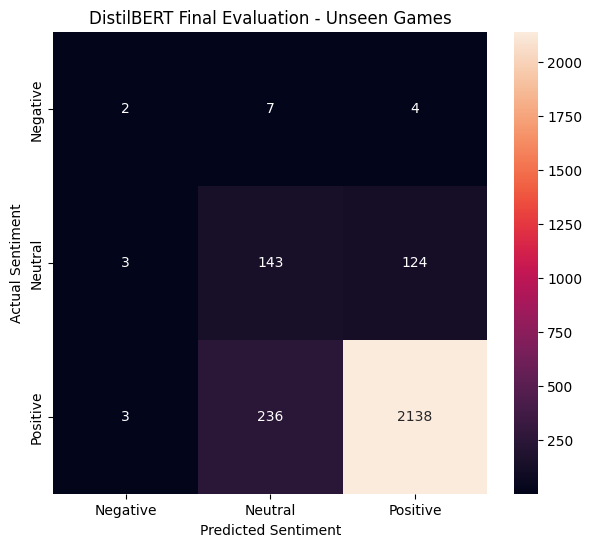

In [26]:
cm = confusion_matrix(
    y_true_unseen,
    y_pred_unseen,
    labels=[0, 1, 2]
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=[
        'Negative',
        'Neutral',
        'Positive'
    ],
    yticklabels=[
        'Negative',
        'Neutral',
        'Positive'
    ]
)

plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title(
    'DistilBERT Final Evaluation - Unseen Games'
)

plt.show()

Per-game sentiment distribution

In [27]:
game_sentiment_counts = (
    unseen_prediction_df
    .groupby(
        [
            'game_id',
            'game_name',
            'predicted_sentiment'
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

game_sentiment_counts = (
    game_sentiment_counts
    .reindex(
        columns=[
            'negative',
            'neutral',
            'positive'
        ],
        fill_value=0
    )
)

display(
    game_sentiment_counts.head(20)
)

,predicted_sentiment,negative,neutral,positive
game_id,game_name,,,
124,Rogue Legacy 2,0,1,65
193,Sonic Mania Plus,0,1,66
204,I Expect You To Die 3: Cog in the Machine,0,1,5
221,Horizon Forbidden West,0,18,164
255,StarVaders,0,4,20
262,Dragon Age: Inquisition,0,12,89
299,Uncharted: Legacy of Thieves Collection,0,19,116
325,Marvel's Spider-Man: Remastered,0,4,75
343,Not For Broadcast,0,4,12


Convert counts into percentages

In [28]:
game_sentiment_percentages = (
    game_sentiment_counts
    .div(
        game_sentiment_counts.sum(axis=1),
        axis=0
    )
    .mul(100)
    .round(2)
)

game_sentiment_percentages.columns = [
    'negative_pct',
    'neutral_pct',
    'positive_pct'
]

display(
    game_sentiment_percentages.head(20)
)

,,negative_pct,neutral_pct,positive_pct
game_id,game_name,,,
124,Rogue Legacy 2,0.00,1.52,98.48
193,Sonic Mania Plus,0.00,1.49,98.51
204,I Expect You To Die 3: Cog in the Machine,0.00,16.67,83.33
221,Horizon Forbidden West,0.00,9.89,90.11
255,StarVaders,0.00,16.67,83.33
262,Dragon Age: Inquisition,0.00,11.88,88.12
299,Uncharted: Legacy of Thieves Collection,0.00,14.07,85.93
325,Marvel's Spider-Man: Remastered,0.00,5.06,94.94
343,Not For Broadcast,0.00,25.00,75.00


Add review count

In [29]:
game_review_counts = (
    unseen_prediction_df
    .groupby(
        [
            'game_id',
            'game_name'
        ]
    )
    .size()
    .rename('review_count')
)

game_intelligence = (
    game_review_counts
    .to_frame()
    .join(game_sentiment_percentages)
)

display(
    game_intelligence.head(20)
)

,,review_count,negative_pct,neutral_pct,positive_pct
game_id,game_name,,,,
124,Rogue Legacy 2,66,0.00,1.52,98.48
193,Sonic Mania Plus,67,0.00,1.49,98.51
204,I Expect You To Die 3: Cog in the Machine,6,0.00,16.67,83.33
221,Horizon Forbidden West,182,0.00,9.89,90.11
255,StarVaders,24,0.00,16.67,83.33
262,Dragon Age: Inquisition,101,0.00,11.88,88.12
299,Uncharted: Legacy of Thieves Collection,135,0.00,14.07,85.93
325,Marvel's Spider-Man: Remastered,79,0.00,5.06,94.94
343,Not For Broadcast,16,0.00,25.00,75.00


Determine overall game sentiment

In [30]:
def determine_overall_sentiment(row):

    values = {
        'negative': row['negative_pct'],
        'neutral': row['neutral_pct'],
        'positive': row['positive_pct']
    }

    return max(
        values,
        key=values.get
    )

game_intelligence[
    'overall_sentiment'
] = game_intelligence.apply(
    determine_overall_sentiment,
    axis=1
)

display(
    game_intelligence.head(20)
)

,,review_count,negative_pct,neutral_pct,positive_pct,overall_sentiment
game_id,game_name,,,,,
124,Rogue Legacy 2,66,0.00,1.52,98.48,positive
193,Sonic Mania Plus,67,0.00,1.49,98.51,positive
204,I Expect You To Die 3: Cog in the Machine,6,0.00,16.67,83.33,positive
221,Horizon Forbidden West,182,0.00,9.89,90.11,positive
255,StarVaders,24,0.00,16.67,83.33,positive
262,Dragon Age: Inquisition,101,0.00,11.88,88.12,positive
299,Uncharted: Legacy of Thieves Collection,135,0.00,14.07,85.93,positive
325,Marvel's Spider-Man: Remastered,79,0.00,5.06,94.94,positive
343,Not For Broadcast,16,0.00,25.00,75.00,positive


cleaner final game-level table

In [31]:
game_intelligence = (
    game_intelligence
    .reset_index()
)

game_intelligence = game_intelligence[
    [
        'game_id',
        'game_name',
        'review_count',
        'positive_pct',
        'neutral_pct',
        'negative_pct',
        'overall_sentiment'
    ]
]

display(
    game_intelligence
)

,game_id,game_name,review_count,positive_pct,neutral_pct,negative_pct,overall_sentiment
0,124,Rogue Legacy 2,66,98.48,1.52,0.00,positive
1,193,Sonic Mania Plus,67,98.51,1.49,0.00,positive
2,204,I Expect You To Die 3: Cog in the Machine,6,83.33,16.67,0.00,positive
3,221,Horizon Forbidden West,182,90.11,9.89,0.00,positive
4,255,StarVaders,24,83.33,16.67,0.00,positive
5,262,Dragon Age: Inquisition,101,88.12,11.88,0.00,positive
6,299,Uncharted: Legacy of Thieves Collection,135,85.93,14.07,0.00,positive
7,325,Marvel's Spider-Man: Remastered,79,94.94,5.06,0.00,positive
8,343,Not For Broadcast,16,75.00,25.00,0.00,positive
9,366,Ni no Kuni 2: Revenant Kingdom,126,82.54,17.46,0.00,positive


Save final unseen predictions

In [32]:
unseen_predictions_path = (
    f'{PROJECT_PATH}/final_unseen_predictions.csv'
)

unseen_prediction_df.to_csv(
    unseen_predictions_path,
    index=False
)

print(
    "✓ Saved:",
    unseen_predictions_path
)

✓ Saved: /content/drive/MyDrive/Game_Review_NLP/final_unseen_predictions.csv


Save final evaluation metrics

In [33]:
final_metrics = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Macro Precision',
        'Macro Recall',
        'Macro F1'
    ],
    'Score': [
        unseen_accuracy,
        unseen_precision,
        unseen_recall,
        unseen_f1
    ]
})

final_metrics_path = (
    f'{PROJECT_PATH}/final_unseen_metrics.csv'
)

final_metrics.to_csv(
    final_metrics_path,
    index=False
)

display(
    final_metrics.style.format({
        'Score': '{:.4f}'
    })
)

,Metric,Score
0,Accuracy,0.8583
1,Macro Precision,0.5213
2,Macro Recall,0.5276
3,Macro F1,0.5158


Save per-game intelligence

In [34]:
game_intelligence_path = (
    f'{PROJECT_PATH}/unseen_game_intelligence.csv'
)

game_intelligence.to_csv(
    game_intelligence_path,
    index=False
)

print(
    "✓ Saved:",
    game_intelligence_path
)

✓ Saved: /content/drive/MyDrive/Game_Review_NLP/unseen_game_intelligence.csv


Create a final model comparison

In [39]:
import pandas as pd

final_comparison = pd.DataFrame({

    'Model': [
        'Balanced Logistic Regression',
        'Balanced Linear SVM',
        'DistilBERT',
        'DistilBERT + Threshold 0.30',
        'Final DistilBERT - Unseen'
    ],

    'Dataset': [
        'Testing',
        'Testing',
        'Testing',
        'Testing',
        'Unseen'
    ],

    'Accuracy': [
        0.8199,
        0.8798,
        0.8667,
        0.8668,
        0.858271
    ],

    'Macro Precision': [
        0.4480,
        0.4503,
        0.5224,
        0.5549,
        0.521326
    ],

    'Macro Recall': [
        0.4796,
        0.4169,
        0.5133,
        0.5492,
        0.527643
    ],

    'Macro F1': [
        0.4430,
        0.4290,
        0.5061,
        0.5451,
        0.515803
    ]
})

display(
    final_comparison.style.format({
        'Accuracy': '{:.4f}',
        'Macro Precision': '{:.4f}',
        'Macro Recall': '{:.4f}',
        'Macro F1': '{:.4f}'
    })
)

,Model,Dataset,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Balanced Logistic Regression,Testing,0.8199,0.4480,0.4796,0.4430
1,Balanced Linear SVM,Testing,0.8798,0.4503,0.4169,0.4290
2,DistilBERT,Testing,0.8667,0.5224,0.5133,0.5061
3,DistilBERT + Threshold 0.30,Testing,0.8668,0.5549,0.5492,0.5451
4,Final DistilBERT - Unseen,Unseen,0.8583,0.5213,0.5276,0.5158


In [40]:
final_comparison.to_csv(
    f'{PROJECT_PATH}/final_model_comparison.csv',
    index=False
)

print("✓ Final comparison saved.")

✓ Final comparison saved.
